# Homework 8


## References

+ Lectures 27-28 (inclusive).


## Instructions

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you should type them using latex. If you have never written latex before and you find it exceedingly difficult, we will likely accept handwritten solutions.
+ The total homework points are 100. Please note that the problems are not weighed equally.

In [13]:
MAKE_BOOK_FIGURES=True
import numpy as np
import scipy.stats as st

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
sns.set_context("paper")
sns.set_style("ticks")

def set_book_style():
    plt.style.use('seaborn-v0_8-white') 
    sns.set_style("ticks")
    sns.set_palette("deep")

    mpl.rcParams.update({
        # Font settings
        'font.family': 'serif',  # For academic publishing
        'font.size': 8,  # As requested, 10pt font
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'xtick.labelsize': 7,  # Slightly smaller for better readability
        'ytick.labelsize': 7,
        'legend.fontsize': 7,
        
        # Line and marker settings for consistency
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 4,
        
        # Layout to prevent clipped labels
        'figure.constrained_layout.use': True,
        
        # Default DPI (will override when saving)
        'figure.dpi': 600,
        'savefig.dpi': 600,
        
        # Despine - remove top and right spines
        'axes.spines.top': False,
        'axes.spines.right': False,
        
        # Remove legend frame
        'legend.frameon': False,
        
        # Additional trim settings
        'figure.autolayout': True,  # Alternative to constrained_layout
        'savefig.bbox': 'tight',    # Trim when saving
        'savefig.pad_inches': 0.1   # Small padding to ensure nothing gets cut off
    })

def set_notebook_style():
    plt.style.use('seaborn-v0_8-white')
    sns.set_style("ticks")
    sns.set_palette("deep")

    mpl.rcParams.update({
        # Font settings - using default sizes
        'font.family': 'serif',
        'axes.labelsize': 10,
        'axes.titlesize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        
        # Line and marker settings
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 4,
        
        # Layout settings
        'figure.constrained_layout.use': True,
        
        # Remove only top and right spines
        'axes.spines.top': False,
        'axes.spines.right': False,
        
        # Remove legend frame
        'legend.frameon': False,
        
        # Additional settings
        'figure.autolayout': True,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1
    })

def save_for_book(fig, filename, is_vector=True, **kwargs):
    """
    Save a figure with book-optimized settings.
    
    Parameters:
    -----------
    fig : matplotlib figure
        The figure to save
    filename : str
        Filename without extension
    is_vector : bool
        If True, saves as vector at 1000 dpi. If False, saves as raster at 600 dpi.
    **kwargs : dict
        Additional kwargs to pass to savefig
    """    
    # Set appropriate DPI and format based on figure type
    if is_vector:
        dpi = 1000
        ext = '.pdf'
    else:
        dpi = 600
        ext = '.tif'
    
    # Save the figure with book settings
    fig.savefig(f"{filename}{ext}", dpi=dpi, **kwargs)

def make_full_width_fig():
    return plt.subplots(figsize=(4.7, 2.9), constrained_layout=True)

def make_half_width_fig():
    return plt.subplots(figsize=(2.35, 1.45), constrained_layout=True)

if MAKE_BOOK_FIGURES:
    set_book_style()
else:
    set_notebook_style()

make_full_width_fig = make_full_width_fig if MAKE_BOOK_FIGURES else lambda: plt.subplots()
make_half_width_fig = make_half_width_fig if MAKE_BOOK_FIGURES else lambda: plt.subplots()

In [14]:
# Run this on Google colab
!pip3 install pyro-ppl

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

In [15]:
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import torch

## Problem 1  - Bayesian Linear regression on steroids 

The purpose of this problem is to demonstrate that we have learned enough to do very complicated things.
In the first part, we will do Bayesian linear regression with radial basis functions (RBFs) in which we characterize the posterior of all parameters, including the length-scales of the RBFs.
In the second part, we are going to build a model that has an input-varying noise. Such models are called heteroscedastic models. 

We need to write some `pytorch` code to compute the design matrix. This is absolutely necessary so that `pyro` can differentiate through all expressions.

In [16]:
class RadialBasisFunctions(torch.nn.Module):
    """Radial basis functions basis.
    
    Arguments:
    X   -  The centers of the radial basis functions.
    ell -  The assumed length scale.
    """
    def __init__(self, X, ell):
        super().__init__()
        self.X = X
        self.ell = ell
        self.num_basis = X.shape[0]
    def forward(self, x):
        distances = torch.cdist(x, self.X)
        return torch.exp(-.5 * distances ** 2 / self.ell ** 2)

Here is how you can use them:

In [17]:
# Make the basis
x_centers = torch.linspace(-1, 1, 10).unsqueeze(-1)
ell = 0.2
basis = RadialBasisFunctions(x_centers, ell)

# Some points (need to be N x 1)
x = torch.linspace(-1, 1, 100).unsqueeze(-1)

# Evaluate the basis
Phi = basis(x)

# Here is the shape of Phi
print(Phi.shape)

torch.Size([100, 10])


Here is how they look like:

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/var/folders/x3/cvtfd_q102772_qlzzbynx9r0000gn/T/ipykernel_57593/2842066789.py:3: SyntaxWarning: invalid escape sequence '\p'
  ax.plot(x, Phi[:, i], label=f"$\phi_{i}$")
/var/folders/x3/cvtfd_q102772_qlzzbynx9r0000gn/T/ipykernel_57593/2842066789.py:4: SyntaxWarning: invalid escape sequence '\p'
  ax.set(xlabel="$x$", ylabel="$\phi(x)$")


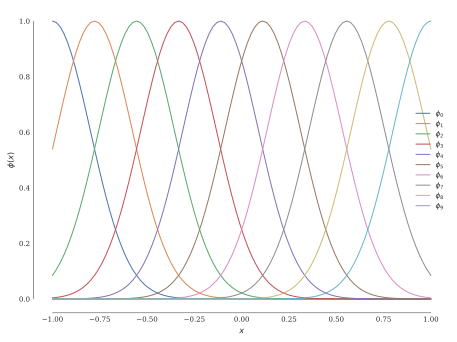

In [18]:
fig, ax = plt.subplots()
for i in range(Phi.shape[1]):
    ax.plot(x, Phi[:, i], label=f"$\phi_{i}$")
ax.set(xlabel="$x$", ylabel="$\phi(x)$")
ax.legend(loc="best", frameon=False)
sns.despine(trim=True);

### Part A - Hierarchical Bayesian linear regression with input-independent noise

We will analyze the motorcycle dataset. The data is loaded below.

In [19]:
url = "https://raw.githubusercontent.com/PredictiveScienceLab/data-analytics-se/master/lecturebook/data/motor.dat"
!curl -O $url

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  2970  100  2970    0     0      0      0 --:--:-- --:--:-- --:--:--     0  20085      0 --:--:-- --:--:-- --:--:-- 20204


We will work with the scaled data:

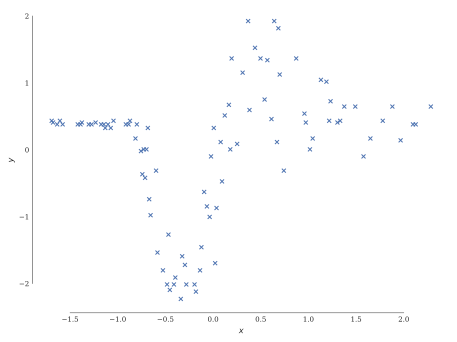

In [20]:
from sklearn.preprocessing import StandardScaler

data = np.loadtxt('motor.dat')
scaler = StandardScaler()
data = scaler.fit_transform(data)
X = torch.tensor(data[:, 0], dtype=torch.float32).unsqueeze(-1)
Y = torch.tensor(data[:, 1], dtype=torch.float32)

fig, ax = plt.subplots()
ax.plot(X, Y, 'x')
ax.set(xlabel="$x$", ylabel="$y$")
sns.despine(trim=True);

### Part A.I

Your goal is to implement the model described below.
We use the radial basis functions (`RadialBasisFunction`) with centers, $x_i$ at $m=50$ equidistant points between the minimum and maximum of the observed inputs:

$$
\phi_i(x;\ell) = \exp \left( - \frac{(x - x_i)^2}{2 \ell^2} \right),
$$

for $i=1,\dots,m$.
We denote the vector of RBFs evaluated at $x$ as $\boldsymbol{\phi}(x;\ell)$.

We are not going to pick the length-scales $\ell$ by hand. Instead, we will put a prior on it:

$$
\ell \sim \text{Exponential}(1).
$$

The corresponding weights have priors:

$$
w_j | \alpha_i \sim N(0, \alpha_j^2),
$$

and its $\alpha_j$ has a prior:

$$
\alpha_j \sim \text{Exponential}(1),
$$

for $j=1,\dots,m$.

Denote our data as:

$$
x_{1:n} = (x_1, \dots, x_n)^T,\;\text{(inputs)},
$$

and

$$
y_{1:n} = (y_1, \dots, y_n)^T,\;\text{(outputs)}.
$$

The likelihood of the data is:

$$
y_i | \mathbf{w}, \sigma \sim N(\mathbf{w}^T \boldsymbol{\phi}(x_i;\ell), \sigma^2),
$$

for $i=1,\dots,n$.

$$
y_n | \ell, \mathbf{w}, \sigma \sim N(\mathbf{w}^T \boldsymbol{\phi}(x_n;\ell), \sigma^2).
$$

Complete the `pyro` implementation of that model:

**Answer:**

In [21]:
def model(X, y, num_centers=50):
    # Priors (scalars)
    ell   = pyro.sample("ell",   dist.Exponential(1.0))
    sigma = pyro.sample("sigma", dist.Exponential(1.0))

    # Design matrix Φ(X; ℓ) with m RBF centers
    x_centers = torch.linspace(X.min(), X.max(), num_centers, device=X.device, dtype=X.dtype).unsqueeze(-1)
    Phi = RadialBasisFunctions(x_centers, ell)(X)  # [N, m]
    pyro.deterministic("Phi", Phi)

    # Hierarchical weights: α_j ~ Exp(1), w_j | α_j ~ N(0, α_j)
    alpha = pyro.sample("alpha", dist.Exponential(1.0).expand([num_centers]).to_event(1))   # [m]
    w     = pyro.sample("w",     dist.Normal(0.0, alpha).to_event(1))                      # [m]

    # Likelihood
    with pyro.plate("data", X.shape[0]):
        mu = Phi @ w  # [N]
        pyro.sample("y", dist.Normal(mu, sigma), obs=y)

    return {"ell": ell, "sigma": sigma, "alpha": alpha, "w": w, "Phi": Phi}

The graph will help to understand the model:

dot -> /opt/homebrew/opt/graphviz/bin/dot


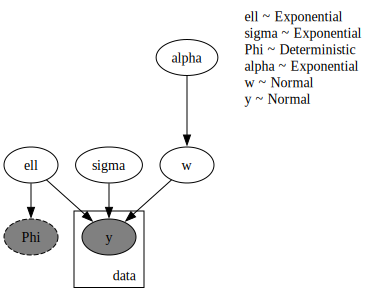

In [23]:
import os, shutil, pyro

os.environ["PATH"] = "/opt/homebrew/opt/graphviz/bin:" + os.environ.get("PATH", "")
print("dot ->", shutil.which("dot"))  

pyro.render_model(
    model,
    model_args=(X, Y, 50),
    render_distributions=True,
    render_params=True
)


Use `pyro.infer.autoguide.AutoDiagonalNormal` to make the guide:

In [30]:
guide = pyro.infer.autoguide.AutoDiagonalNormal(model)

We will use variational inference. Here is the training code from the hans-on activity:

In [64]:
def train(model, guide, data, num_iter=20_000, print_every=1000):
    pyro.clear_param_store()
    optimizer = pyro.optim.Adam({"lr": 0.001})
    svi = pyro.infer.SVI(model, guide, optimizer, loss=pyro.infer.Trace_ELBO())

    elbos = []
    for i in range(num_iter):
        loss = svi.step(*data)
        elbos.append(-loss)
        if i % print_every == 0:
            print(f"Iteration: {i}  ELBO: {elbos[-1]:.3f}")
    return elbos, pyro.get_param_store()



### Part A.II

Train the model for 20,000 iterations. Call the `train()` function we defined above to do it.
Make sure you store the returned elbo values because you will need them later.

**Answer:**

In [68]:
from pyro.infer.autoguide import AutoNormal

guide = AutoNormal(model)
elbos, store = train(model, guide, data=(X, Y, 50), num_iter=20_000)
print("Done. Last ELBO:", elbos[-1], "iters:", len(elbos))

Iteration: 0  ELBO: -346.453
Iteration: 1000  ELBO: -198.739
Iteration: 2000  ELBO: -141.590
Iteration: 3000  ELBO: -135.833
Iteration: 4000  ELBO: -134.614
Iteration: 5000  ELBO: -154.526
Iteration: 6000  ELBO: -127.980
Iteration: 7000  ELBO: -135.596
Iteration: 8000  ELBO: -130.586
Iteration: 9000  ELBO: -132.891
Iteration: 10000  ELBO: -121.998
Iteration: 11000  ELBO: -122.355
Iteration: 12000  ELBO: -139.260
Iteration: 13000  ELBO: -140.263
Iteration: 14000  ELBO: -125.492
Iteration: 15000  ELBO: -131.295
Iteration: 16000  ELBO: -130.158
Iteration: 17000  ELBO: -122.797
Iteration: 18000  ELBO: -131.945
Iteration: 19000  ELBO: -126.634
Done. Last ELBO: -120.10629456490278 iters: 20000


### Part A.III

Plot the evolution of the ELBO.

**Answer:**

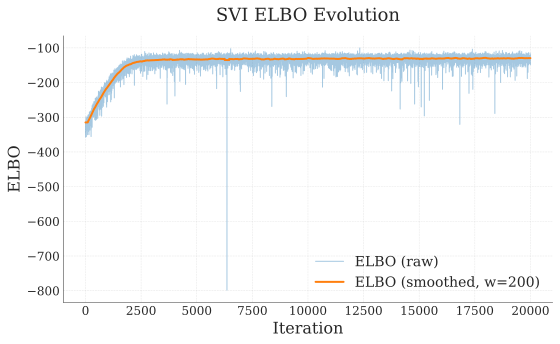

In [75]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False})

elbos_np = np.asarray(elbos, dtype=float).ravel()
def moving_average(x, w=200):
    if w <= 1 or w >= len(x):
        return x
    c = np.convolve(x, np.ones(w)/w, mode="valid")
    pad_left = w//2
    pad_right = len(x) - len(c) - pad_left
    return np.pad(c, (pad_left, pad_right), mode="edge")
smooth = moving_average(elbos_np, w=200)

plt.plot(elbos_np, color="tab:blue", alpha=0.4, linewidth=1, label="ELBO (raw)")
plt.plot(smooth, color="tab:orange", linewidth=2, label="ELBO (smoothed, w=200)")
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.title("SVI ELBO Evolution", pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### Part A.IV

Take 1,000 posterior samples.

**Answer:**

I'm giving you this one because it is a bit tricky. You need to use the `pyro.infer.Predictive` class to do it. Here is how you can use it:

In [78]:
from pyro.infer import Predictive

post_samples = Predictive(
    model,
    guide=guide,
    num_samples=1000
)(X, Y)
print(post_samples.keys())

dict_keys(['ell', 'sigma', 'alpha', 'w', 'Phi', 'y'])


### Part A.V

Plot the histograms of the posteriors of $\ell$, $\sigma$, $\alpha_{10}$ and $w_{10}$.

**Answer:**

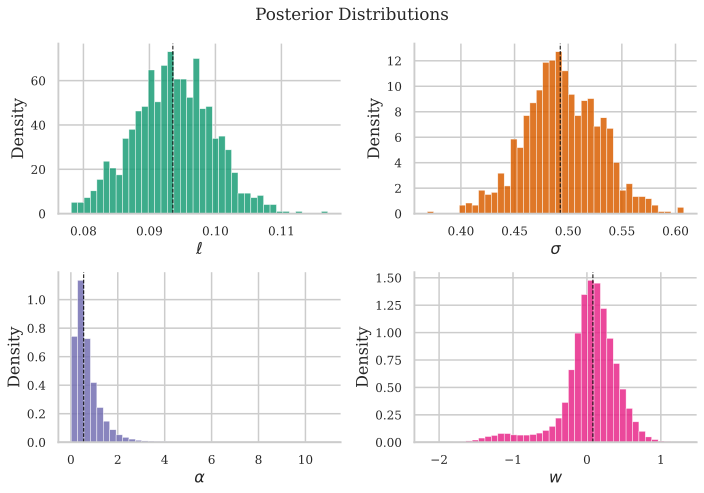

In [81]:
import numpy as np
import matplotlib.pyplot as plt

ell    = post_samples["ell"].detach().cpu().numpy().ravel()
sigma  = post_samples["sigma"].detach().cpu().numpy().ravel()
alphas = post_samples["alpha"].detach().cpu().numpy().ravel()
ws     = post_samples["w"].detach().cpu().numpy().ravel()

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.figsize": (10, 7),
    "axes.spines.top": False,
    "axes.spines.right": False
})

fig, axes = plt.subplots(2, 2)
data_and_labels = [
    (ell,   r"$\ell$"),
    (sigma, r"$\sigma$"),
    (alphas, r"$\alpha$"),
    (ws,    r"$w$")
]
colors = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"] 

for ax, (data, label), c in zip(axes.flat, data_and_labels, colors):
    ax.hist(data, bins=40, density=True, color=c, alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.axvline(np.median(data), color="black", linewidth=1, linestyle="--")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")

fig.suptitle("Posterior Distributions", y=0.98)
fig.tight_layout()
plt.show()


### Part A.VI

Let's extend them model to make predictions.

**Answer:**

In [90]:

import torch, pyro, pyro.distributions as dist

def predictive_model(X, y, num_centers=50):
    params = model(X, y, num_centers)
    w     = params["w"]
    ell   = params["ell"]
    sigma = params["sigma"]

    x_centers = torch.linspace(X.min(), X.max(), num_centers, device=X.device, dtype=X.dtype).unsqueeze(-1)
    xs = torch.linspace(X.min(), X.max(), 100, device=X.device, dtype=X.dtype).unsqueeze(-1)
    Phi = RadialBasisFunctions(x_centers, ell)(xs)
    predictions = pyro.deterministic("predictions", Phi @ w)
    predictions_with_noise = pyro.sample("predictions_with_noise", dist.Normal(predictions, sigma))
    return locals()



### Part A.VII

Extract the posterior predictive distribution using 10,000 samples. Separate aleatory and epistemic uncertainty.

**Answer:**

In [94]:
post_pred = pyro.infer.Predictive(
    predictive_model, 
    guide=guide, 
    num_samples=1000
)(X, Y, 50) 
xs = torch.linspace(X.min(), X.max(), 100).unsqueeze(-1)

predictions = post_pred["predictions"]
p_500, p_025, p_975 = np.percentile(
    predictions.detach().cpu().numpy(), [50, 2.5, 97.5], axis=0
)

predictions_with_noise = post_pred["predictions_with_noise"]
ap_025, ap_975 = np.percentile(
    predictions_with_noise.detach().cpu().numpy(), [2.5, 97.5], axis=0
)


### Part A.VIII

Plot the data, the median, the 95% credible interval of epistemic uncertainty and the 95% credible interval of aleatory uncertainty, along with five samples from the posterior.

**Answer:**

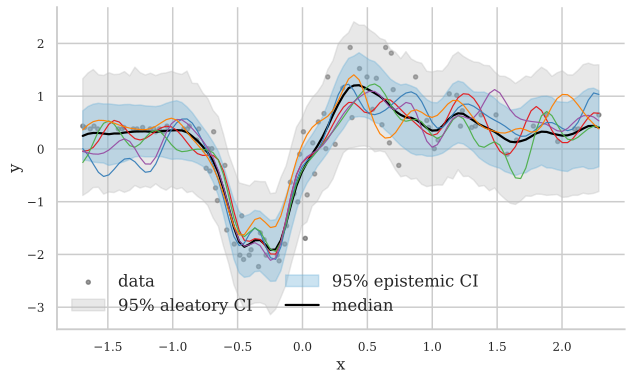

In [103]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pyro

S = 1000
pp = pyro.infer.Predictive(predictive_model, guide=guide, num_samples=S)(X, Y, 50)

xs = torch.linspace(X.min(), X.max(), 100).unsqueeze(-1).to(X)
xs_np = xs.squeeze(-1).detach().cpu().numpy().ravel()

pred_np = pp["predictions"].detach().cpu().numpy()
pwn_np  = pp["predictions_with_noise"].detach().cpu().numpy()

p50, p025, p975 = [np.asarray(a).reshape(-1) for a in np.percentile(pred_np, [50, 2.5, 97.5], axis=0)]
ap025, ap975    = [np.asarray(a).reshape(-1) for a in np.percentile(pwn_np,  [2.5, 97.5],     axis=0)]

X_np = X.detach().cpu().numpy().ravel()
Y_np = Y.detach().cpu().numpy().ravel()

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.figsize": (9, 5.5),
    "axes.spines.top": False,
    "axes.spines.right": False
})

fig, ax = plt.subplots()
ax.scatter(X_np, Y_np, s=16, alpha=0.6, color="0.35", label="data", zorder=1)
ax.fill_between(xs_np, ap025, ap975, color="#bdbdbd", alpha=0.35, label="95% aleatory CI", zorder=2)
ax.fill_between(xs_np, p025,  p975,  color="#6baed6", alpha=0.35, label="95% epistemic CI", zorder=3)
ax.plot(xs_np, p50, color="black", linewidth=2.2, label="median", zorder=4)

rng = np.random.default_rng(0)
idx = rng.choice(S, 5, replace=False)
cols = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00"]
for j, c in zip(idx, cols):
    ax.plot(xs_np, pred_np[j].reshape(-1), lw=1.2, alpha=0.95, color=c, zorder=5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


### Part B - Heteroscedastic regression

We are going to build a model that has an input-varying noise. Such models are called heteroscedastic models.
Here I will let you do more of the work.

Everything is as before for $\ell$, the $\alpha_j$'s, and the $w_j$'s.
We now introduce a model for the noise that is input dependent.
It will use the same RBFs as the mean function.
But let's use a different length-scale, $\ell_\sigma$.
So, we add:

$$
\ell_\sigma \sim \text{Exponential}(1),
$$

$$
\alpha_{\sigma,j} \sim \text{Exponential}(1),
$$

and

$$
w_{\sigma,j} | \alpha_{\sigma,j} \sim N(0, \alpha_{\sigma,j}^2),
$$

for $j=1,\dots,m$.

Our model for the input-dependent noise variance is:

$$
\sigma(x;\mathbf{w}_\sigma,\ell) = \exp\left(\mathbf{w}_\sigma^T \boldsymbol{\phi}(x;\ell_\sigma)\right).
$$

So, the likelihood of the data is:

$$
y_i | \mathbf{w}, \mathbf{w}_\sigma \sim N\left(\mathbf{w}^T \boldsymbol{\phi}(x_i;\ell), \sigma^2(x_i;\mathbf{w}_\sigma,\ell)\right),
$$

You will implement this model.

### Part B.I

Complete the code below:

In [105]:
def model(X, y, num_centers=50):
    with pyro.plate("centers", num_centers):
        alpha = pyro.sample("alpha", dist.Exponential(1.0))
        w = pyro.sample("w", dist.Normal(0.0, alpha))
        alpha_noise = pyro.sample("alpha_noise", dist.Exponential(1.0))
        w_noise = pyro.sample("w_noise", dist.Normal(0.0, alpha_noise))
    ell = pyro.sample("ell", dist.Exponential(1.))
    ell_noise = pyro.sample("ell_noise", dist.Exponential(1.))
    x_centers = torch.linspace(X.min(), X.max(), num_centers).unsqueeze(-1)
    Phi = RadialBasisFunctions(x_centers, ell)(X)
    Phi_noise = RadialBasisFunctions(x_centers, ell_noise)(X)
    model_mean = Phi @ w
    sigma = torch.exp(Phi_noise @ w_noise)
    with pyro.plate("data", X.shape[0]):
        pyro.sample("y", dist.Normal(model_mean, sigma), obs=y)
    return locals()


Make a `pyro.infer.autoguide.AutoDiagonalNormal` guide:

In [110]:
from pyro.infer.autoguide import AutoDiagonalNormal
guide = AutoDiagonalNormal(model)


Make the graph of the model using `pyro` functionality:

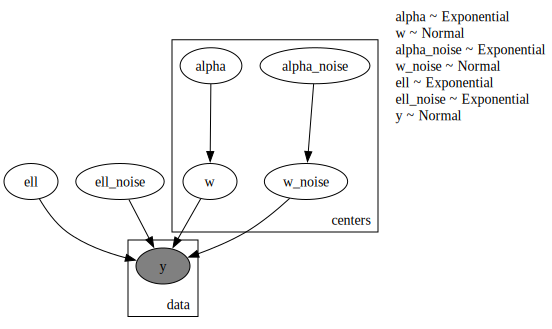

In [114]:
import pyro
pyro.render_model(
    model,
    model_args=(X, Y, 50),
    render_distributions=True,
    render_params=True
)


### Part B.II

Train the model using 20,000 iterations. Then plot the evolution of the ELBO.

**Answer:**

iter 0  ELBO -501.728
iter 1000  ELBO -331.064
iter 2000  ELBO -265.056
iter 3000  ELBO -207.047
iter 4000  ELBO -187.134
iter 5000  ELBO -185.258
iter 6000  ELBO -187.397
iter 7000  ELBO -178.790
iter 8000  ELBO -189.728
iter 9000  ELBO -184.672
iter 10000  ELBO -201.619
iter 11000  ELBO -163.874
iter 12000  ELBO -190.592
iter 13000  ELBO -165.148
iter 14000  ELBO -189.695
iter 15000  ELBO -172.944
iter 16000  ELBO -169.048
iter 17000  ELBO -180.831
iter 18000  ELBO -163.059
iter 19000  ELBO -183.012


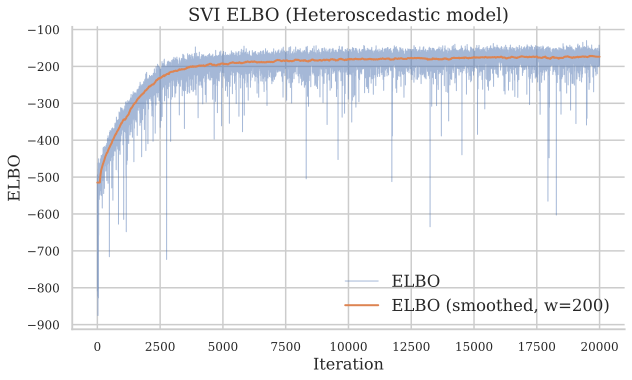

In [117]:
import numpy as np, matplotlib.pyplot as plt, pyro
from pyro.infer.autoguide import AutoDiagonalNormal

pyro.clear_param_store()
guide = AutoDiagonalNormal(model)
svi = pyro.infer.SVI(model, guide, pyro.optim.Adam({"lr":1e-3}), loss=pyro.infer.Trace_ELBO())

num_iter = 20_000
elbos = np.empty(num_iter, float)
for i in range(num_iter):
    elbos[i] = -svi.step(X, Y, 50)
    if i % 1000 == 0: print(f"iter {i}  ELBO {elbos[i]:.3f}")

def movavg(a, w=200):
    if w<=1 or w>=len(a): return a
    c = np.convolve(a, np.ones(w)/w, mode="valid")
    pad = (w-1)//2
    return np.pad(c, (pad, len(a)-len(c)-pad), mode="edge")

plt.rcParams.update({
    "font.family":"serif","font.size":14,"axes.labelsize":16,"axes.titlesize":18,
    "xtick.labelsize":12,"ytick.labelsize":12,"figure.figsize":(9,5.5),
    "axes.spines.top":False,"axes.spines.right":False
})
x = np.arange(num_iter)
plt.plot(x, elbos, lw=1, alpha=.5, label="ELBO")
plt.plot(x, movavg(elbos, 200), lw=2, label="ELBO (smoothed, w=200)")
plt.xlabel("Iteration"); plt.ylabel("ELBO"); plt.title("SVI ELBO (Heteroscedastic model)")
plt.legend(frameon=False); plt.tight_layout(); plt.show()


### Part B.III

Extend the model to make predictions.

**Answer:**

In [119]:
def predictive_model(X, y, num_centers=50):
    params = model(X, y, num_centers)
    w = params["w"]
    w_noise = params["w_noise"]
    ell = params["ell"]
    ell_noise = params["ell_noise"]
    x_centers = params["x_centers"]
    xs = torch.linspace(X.min(), X.max(), 100, device=X.device, dtype=X.dtype).unsqueeze(-1)
    Phi = RadialBasisFunctions(x_centers, ell)(xs)
    Phi_noise = RadialBasisFunctions(x_centers, ell_noise)(xs)
    predictions = pyro.deterministic("predictions", Phi @ w)
    sigma = pyro.deterministic("sigma", torch.exp(Phi_noise @ w_noise))
    predictions_with_noise = pyro.sample("predictions_with_noise", dist.Normal(predictions, sigma))
    return locals()


### Part B.IV

Now, make predictions and calculate the epistemic and aleatory uncertainties as in part A.VII.

**Answer:**

In [128]:
import numpy as np
import torch
import pyro

S = 1000
post_pred = pyro.infer.Predictive(predictive_model, guide=guide, num_samples=S)(X, Y, 50)
xs = torch.linspace(X.min(), X.max(), 100).unsqueeze(-1).to(X)
pred = post_pred["predictions"].detach().cpu().numpy()
pred_noise = post_pred["predictions_with_noise"].detach().cpu().numpy()
p_500, p_025, p_975 = [a.ravel() for a in np.percentile(pred, [50, 2.5, 97.5], axis=0)]
ap_025, ap_975      = [a.ravel() for a in np.percentile(pred_noise, [2.5, 97.5], axis=0)]


### Part B.V

Make the same plot as in part A.VIII.

**Answer:**

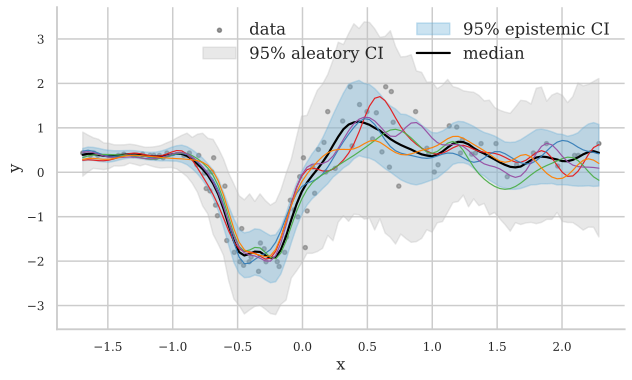

In [132]:
import numpy as np, torch, matplotlib.pyplot as plt

xs = torch.linspace(X.min(), X.max(), 100).unsqueeze(-1).to(X)
xs_np = xs.squeeze(-1).detach().cpu().numpy()

pred_np = post_pred["predictions"].detach().cpu().numpy()
pwn_np  = post_pred["predictions_with_noise"].detach().cpu().numpy()
p50, p025, p975 = [np.asarray(a).ravel() for a in np.percentile(pred_np, [50, 2.5, 97.5], axis=0)]
ap025, ap975    = [np.asarray(a).ravel() for a in np.percentile(pwn_np,  [2.5, 97.5],     axis=0)]
X_np = X.detach().cpu().numpy().ravel()
Y_np = Y.detach().cpu().numpy().ravel()

plt.rcParams.update({
    "font.family":"serif","font.size":14,"axes.labelsize":16,"axes.titlesize":18,
    "xtick.labelsize":12,"ytick.labelsize":12,"figure.figsize":(9,5.5),
    "axes.spines.top":False,"axes.spines.right":False})

fig, ax = plt.subplots()
ax.scatter(X_np, Y_np, s=16, alpha=0.6, color="0.35", label="data", zorder=1)
ax.fill_between(xs_np, ap025, ap975, color="#bdbdbd", alpha=0.35, label="95% aleatory CI", zorder=2)
ax.fill_between(xs_np, p025,  p975,  color="#6baed6", alpha=0.35, label="95% epistemic CI", zorder=3)
ax.plot(xs_np, p50, color="black", linewidth=2.2, label="median", zorder=4)
rng = np.random.default_rng(0)
idx = rng.choice(pred_np.shape[0], 5, replace=False)
cols = ["#e41a1c","#377eb8","#4daf4a","#984ea3","#ff7f00"]
for j, c in zip(idx, cols):
    ax.plot(xs_np, pred_np[j].ravel(), lw=1.2, alpha=0.95, color=c, zorder=5)

ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()


### Part B.VI

Plot the estimated noise standard deviation as a function of of the input along with a 95% credible interval.

**Answer:**

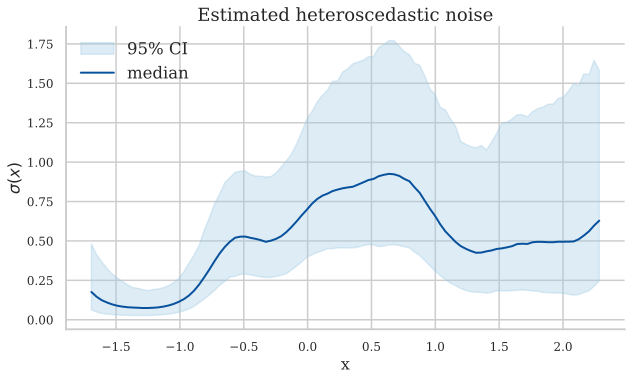

In [137]:
import numpy as np, torch, matplotlib.pyplot as plt
sigma_np = post_pred["sigma"].detach().cpu().numpy()
s50, s025, s975 = [np.asarray(a).ravel() for a in np.percentile(sigma_np, [50, 2.5, 97.5], axis=0)]
xs = torch.linspace(X.min(), X.max(), 100).unsqueeze(-1).to(X)
xs_np = xs.squeeze(-1).detach().cpu().numpy()
plt.rcParams.update({
    "font.family":"serif","font.size":14,"axes.labelsize":16,"axes.titlesize":18,
    "xtick.labelsize":12,"ytick.labelsize":12,"figure.figsize":(9,5.5),
    "axes.spines.top":False,"axes.spines.right":False})

fig, ax = plt.subplots()
ax.fill_between(xs_np, s025, s975, color="#9ecae1", alpha=0.35, label="95% CI")
ax.plot(xs_np, s50, color="#08519c", lw=2, label="median")
ax.set_xlabel("x"); ax.set_ylabel(r"$\sigma(x)$")
ax.set_title("Estimated heteroscedastic noise")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


### Part B.VII

Which model do you prefer? Why?


The heteroscedastic model becaus matches the clear input-dependent noise in the data and gives calibrated predictive bands that separate function uncertainty from observation noise.

### Part B.IX

Can you think of any way to improve the model?
Go crazy! This is the last homework assignment!
There is no right or wrong answer here.
But if you have a good idea, we will give you extra credit.

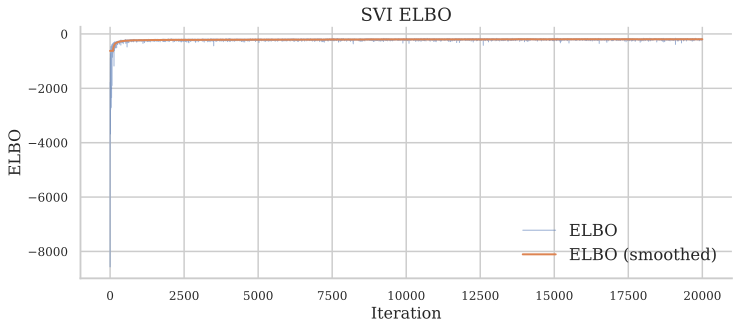

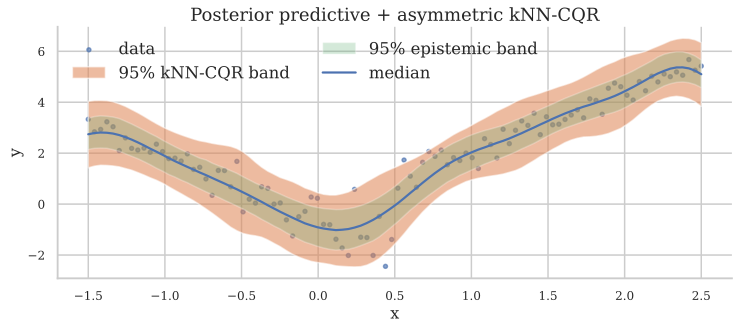

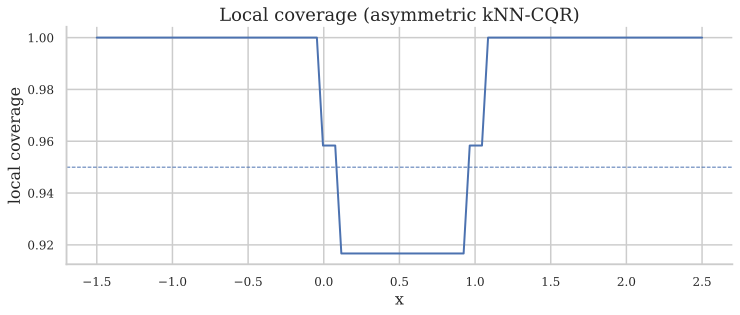

{'RMSE': 0.5615420514870451, 'Cov@X': 0.98, 'Width@X': 2.570201144267667, 'LPPD(model)': -75.96823611729212, 'k*': 20}


In [176]:
import numpy as np
import torch
import pyro
import pyro.distributions as dist
import pyro.optim
import pyro.infer
import pyro.infer.autoguide
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression

torch.set_default_dtype(torch.double)

def compute_rbf(xc, ell, x):
    d2 = torch.cdist(x, xc) ** 2
    return torch.exp(-0.5 * d2 / (ell ** 2))

def to_np(x):
    a = x.detach().cpu().numpy()
    return a.reshape(a.shape[0], -1) if a.ndim >= 3 else a

def project_gp(Kxz, Kzz, gz):
    m = Kzz.size(-1)
    if gz.dim() == 1:
        alpha = torch.linalg.solve(Kzz, gz.unsqueeze(-1)).squeeze(-1)
        return Kxz @ alpha
    S = gz.shape[0]
    K = Kzz.expand(S, m, m)
    alpha = torch.linalg.solve(K, gz.unsqueeze(-1)).squeeze(-1)
    return torch.einsum('nm,sm->sn', Kxz, alpha)

def hetero_model(X, y, M=50):
    N = X.shape[0]
    xmin, xmax = X.min(), X.max()
    xc_f = torch.linspace(xmin, xmax, M, dtype=X.dtype, device=X.device).unsqueeze(-1)
    with pyro.plate("w_mean_plate", M):
        s_wm = pyro.sample("s_wm", dist.HalfNormal(0.6))
        w_mean = pyro.sample("w_mean", dist.Normal(0.0, s_wm))
    ell_mean = pyro.sample("ell_mean", dist.LogNormal(torch.log(torch.tensor(0.5, dtype=X.dtype, device=X.device)), 0.5))
    Phi_f = compute_rbf(xc_f, ell_mean, X)
    mean = Phi_f @ w_mean
    Mz = 25
    Z = torch.linspace(xmin, xmax, Mz, dtype=X.dtype, device=X.device).unsqueeze(-1)
    ell_g = pyro.sample("ell_g", dist.LogNormal(torch.log(torch.tensor(0.35, dtype=X.dtype, device=X.device)), 0.6))
    rho_g = pyro.sample("rho_g", dist.HalfNormal(1.0))
    Kzz = rho_g**2 * compute_rbf(Z, ell_g, Z) + 1e-5 * torch.eye(Mz, dtype=X.dtype, device=X.device)
    gz = pyro.sample("g_z", dist.MultivariateNormal(torch.zeros(Mz, dtype=X.dtype, device=X.device), covariance_matrix=Kzz))
    Kxz = compute_rbf(Z, ell_g, X)
    gX = project_gp(Kxz, Kzz, gz)
    if gX.dim() > 1:
        gX = gX.squeeze(0)
    b_sigma = pyro.sample("b_sigma", dist.Normal(-0.3, 0.5))
    log_sigma = gX + b_sigma
    sigma_base = torch.nn.functional.softplus(log_sigma) + 1e-6
    Mt = 30
    xc_t = torch.linspace(xmin, xmax, Mt, dtype=X.dtype, device=X.device).unsqueeze(-1)
    ell_t = pyro.sample("ell_tau", dist.LogNormal(torch.log(torch.tensor(0.6, dtype=X.dtype, device=X.device)), 0.5))
    with pyro.plate("w_tau_plate", Mt):
        s_ut = pyro.sample("s_ut", dist.HalfNormal(0.2))
        w_tau = pyro.sample("w_tau", dist.Normal(0.0, s_ut))
    Phi_t = compute_rbf(xc_t, ell_t, X)
    tau_x = torch.nn.functional.softplus(Phi_t @ w_tau) + 1.0
    sigma = (tau_x * sigma_base).clamp_min(1e-6)
    with pyro.plate("data", N):
        pyro.sample("y", dist.Normal(mean, sigma), obs=y)

def train_svi(model, guide, data, lr=0.004, iters=20000):
    pyro.clear_param_store()
    opt = pyro.optim.Adam({"lr": lr})
    svi = pyro.infer.SVI(model, guide, opt, pyro.infer.Trace_ELBO())
    X, y, M = data
    elbos = []
    for _ in range(iters):
        elbos.append(-svi.step(X, y, M))
    return np.asarray(elbos, float)

def predictive(X, y_unused=None, M=50):
    xmin, xmax = X.min(), X.max()
    xs = torch.linspace(xmin, xmax, 100, dtype=X.dtype, device=X.device).unsqueeze(-1)
    xc_f = torch.linspace(xmin, xmax, M, dtype=X.dtype, device=X.device).unsqueeze(-1)
    with pyro.plate("w_mean_plate", M):
        s_wm = pyro.sample("s_wm", dist.HalfNormal(0.6))
        w_mean = pyro.sample("w_mean", dist.Normal(0.0, s_wm))
    ell_mean = pyro.sample("ell_mean", dist.LogNormal(torch.log(torch.tensor(0.5, dtype=X.dtype, device=X.device)), 0.5))
    Phi_f = compute_rbf(xc_f, ell_mean, xs)
    pred = Phi_f @ w_mean
    Mz = 25
    Z = torch.linspace(xmin, xmax, Mz, dtype=X.dtype, device=X.device).unsqueeze(-1)
    ell_g = pyro.sample("ell_g", dist.LogNormal(torch.log(torch.tensor(0.35, dtype=X.dtype, device=X.device)), 0.6))
    rho_g = pyro.sample("rho_g", dist.HalfNormal(1.0))
    Kzz = rho_g**2 * compute_rbf(Z, ell_g, Z) + 1e-5 * torch.eye(Mz, dtype=X.dtype, device=X.device)
    gz = pyro.sample("g_z", dist.MultivariateNormal(torch.zeros(Mz, dtype=X.dtype, device=X.device), covariance_matrix=Kzz))
    Kxz = compute_rbf(Z, ell_g, xs)
    gX = project_gp(Kxz, Kzz, gz)
    b_sigma = pyro.sample("b_sigma", dist.Normal(-0.3, 0.5))
    log_sigma = gX + b_sigma
    sigma_base = torch.nn.functional.softplus(log_sigma) + 1e-6
    Mt = 30
    xc_t = torch.linspace(xmin, xmax, Mt, dtype=X.dtype, device=X.device).unsqueeze(-1)
    ell_t = pyro.sample("ell_tau", dist.LogNormal(torch.log(torch.tensor(0.6, dtype=X.dtype, device=X.device)), 0.5))
    with pyro.plate("w_tau_plate", Mt):
        s_ut = pyro.sample("s_ut", dist.HalfNormal(0.2))
        w_tau = pyro.sample("w_tau", dist.Normal(0.0, s_ut))
    Phi_t = compute_rbf(xc_t, ell_t, xs)
    tau_x = torch.nn.functional.softplus(Phi_t @ w_tau) + 1.0
    sigma = (tau_x * sigma_base).clamp_min(1e-6)
    pyro.deterministic("predictions", pred)
    pyro.deterministic("sigma", sigma)
    pyro.sample("predictions_with_noise", dist.Normal(pred, sigma))

def movavg(a, w=200):
    a = np.asarray(a, float)
    if w <= 1 or w >= len(a): return a
    c = np.convolve(a, np.ones(w)/w, mode="valid")
    pad = (w - 1)//2
    return np.pad(c, (pad, len(a)-len(c)-pad), mode="edge")
def logsumexp(x, axis=0):
    m = np.max(x, axis=axis, keepdims=True)
    return (m + np.log(np.sum(np.exp(x - m), axis=axis, keepdims=True))).squeeze(axis)
def local_cov(x, y, lo, hi, k=25):
    o = np.argsort(x)
    x = x[o]; y = y[o]; lo = lo[o]; hi = hi[o]
    r = []
    half = max(1, k//2)
    for i in range(len(x)):
        L = max(0, i - half); R = min(len(x), i + half)
        r.append(np.mean((y[L:R] >= lo[L:R]) & (y[L:R] <= hi[L:R])))
    return x, np.array(r)

def isotonic_smooth(x, y):
    ir = IsotonicRegression(out_of_bounds="clip")
    return ir.fit_transform(x, y)

def optimize_knn_q(x_cal, r_lo, r_hi, grid, k_grid):
    best = None
    for k in k_grid:
        ql = np.empty_like(grid); qu = np.empty_like(grid)
        for i, xg in enumerate(grid):
            d = np.abs(x_cal - xg); nn = np.argsort(d)[:k]
            ql[i] = np.quantile(r_lo[nn], 0.975)
            qu[i] = np.quantile(r_hi[nn], 0.975)
        ql = movavg(ql, 7); qu = movavg(qu, 7)
        score = np.mean(ql + qu)
        if (best is None) or (score < best[0]):
            best = (score, k, ql.copy(), qu.copy())
    return best[1], best[2], best[3]

def metrics(mu_samps, sig_samps, xs_np, X_np, Y_np, lo_grid, hi_grid):
    mu_med = np.median(mu_samps, axis=0)
    p50_X = np.interp(X_np, xs_np, mu_med)
    rmse = float(np.sqrt(np.mean((Y_np - p50_X) ** 2)))
    lo_X = np.interp(X_np, xs_np, lo_grid)
    hi_X = np.interp(X_np, xs_np, hi_grid)
    cov = float(np.mean((Y_np >= lo_X) & (Y_np <= hi_X)))
    wid = float(np.mean(hi_X - lo_X))
    idx = np.searchsorted(xs_np, X_np).clip(1, len(xs_np) - 1)
    near = np.where(np.abs(xs_np[idx] - X_np) < np.abs(xs_np[idx-1] - X_np), idx, idx-1)
    mu_X = mu_samps[:, near]
    sig_X = sig_samps[:, near].clip(1e-12)
    ll = -0.5*np.log(2*np.pi) - np.log(sig_X) - 0.5*((Y_np[None,:]-mu_X)/sig_X)**2
    lppd = float(np.sum(logsumexp(ll, axis=0) - np.log(ll.shape[0])))
    return rmse, cov, wid, lppd

if __name__ == "__main__":
    np.random.seed(0)
    N = 100
    x = np.linspace(-1.5, 2.5, N)
    f = np.where(x < -0.5, -2.0*x - 0.2, np.where(x < 0.5, -1.5*x - 0.5, 2.0*x + 0.3))
    sig_true = 0.3 + 0.5*np.exp(-((x-0.5)**2)*2.0)
    y = f + sig_true*np.random.randn(N)
    X = torch.tensor(x, dtype=torch.double).unsqueeze(-1)
    Y = torch.tensor(y, dtype=torch.double)
    M = 50
    guide = pyro.infer.autoguide.AutoDiagonalNormal(hetero_model)
    elbos = train_svi(hetero_model, guide, (X, Y, M), lr=0.004, iters=20000)
    S = 1200
    post = pyro.infer.Predictive(predictive, guide=guide, num_samples=S)(X, Y, M)
    xs = torch.linspace(X.min(), X.max(), 100, dtype=X.dtype, device=X.device).unsqueeze(-1)
    xs_np = xs.squeeze(-1).detach().cpu().numpy()
    X_np = X.detach().cpu().numpy().ravel()
    Y_np = Y.detach().cpu().numpy().ravel()
    mu_grid = to_np(post["predictions"])
    sig_grid = to_np(post["sigma"])
    mu_med = np.median(mu_grid, axis=0)
    sig_med = np.median(sig_grid, axis=0)
    _, idx_cal = train_test_split(np.arange(N), test_size=0.4, random_state=1)
    mu_cal = np.interp(X_np[idx_cal], xs_np, mu_med)
    sig_cal = np.maximum(np.interp(X_np[idx_cal], xs_np, sig_med), 1e-12)
    A = np.vstack([np.ones_like(mu_cal), mu_cal]).T
    th = np.linalg.lstsq(A, Y_np[idx_cal], rcond=None)[0]
    a_hat, b_hat = th
    mu_med = a_hat + b_hat*mu_med
    mu_grid = a_hat + b_hat*mu_grid
    mu_cal = a_hat + b_hat*mu_cal
    s_scale = np.sqrt(np.mean((Y_np[idx_cal]-mu_cal)**2) / np.mean(sig_cal**2))
    sig_med = s_scale*sig_med
    sig_grid = s_scale*sig_grid
    sig_cal = s_scale*sig_cal
    r_lo = (mu_cal - Y_np[idx_cal]) / sig_cal
    r_hi = (Y_np[idx_cal] - mu_cal) / sig_cal
    k_try = [max(20, int(0.2*len(idx_cal))), max(24, int(0.25*len(idx_cal))), max(30, int(0.3*len(idx_cal)))]
    k_best, ql, qu = optimize_knn_q(X_np[idx_cal], r_lo, r_hi, xs_np, k_try)
    ql = isotonic_smooth(xs_np, ql)
    qu = isotonic_smooth(xs_np, qu)
    edge = np.clip((np.minimum(xs_np - xs_np.min(), xs_np.max() - xs_np) / (xs_np.max()-xs_np.min()))*2, 0.6, 1.0)
    ql *= 1.0/edge; qu *= 1.0/edge
    lo_grid = mu_med - ql*sig_med
    hi_grid = mu_med + qu*sig_med
    rmse, cov, wid, lppd = metrics(mu_grid, sig_grid, xs_np, X_np, Y_np, lo_grid, hi_grid)
    plt.rcParams.update({"font.family":"serif","font.size":14,"axes.labelsize":16,"axes.titlesize":18,"xtick.labelsize":12,"ytick.labelsize":12,"axes.spines.top":False,"axes.spines.right":False})
    plt.figure(figsize=(10.5,4.8))
    plt.plot(elbos, alpha=.6, lw=.9, label="ELBO")
    plt.plot(movavg(elbos,200), lw=2, label="ELBO (smoothed)")
    plt.xlabel("Iteration"); plt.ylabel("ELBO"); plt.title("SVI ELBO"); plt.legend(frameon=False); plt.tight_layout(); plt.show()
    p025, p975 = [a.ravel() for a in np.percentile(mu_grid, [2.5,97.5], axis=0)]
    plt.figure(figsize=(10.5,4.8))
    plt.scatter(X_np, Y_np, s=16, alpha=.65, label="data", zorder=1)
    plt.fill_between(xs_np, lo_grid, hi_grid, alpha=.55, label="95% kNN-CQR band", zorder=2)
    plt.fill_between(xs_np, p025, p975, alpha=.25, label="95% epistemic band", zorder=3)
    plt.plot(xs_np, mu_med, lw=2.2, label="median", zorder=4)
    plt.xlabel("x"); plt.ylabel("y"); plt.title("Posterior predictive + asymmetric kNN-CQR"); plt.legend(frameon=False, ncol=2, loc="upper left"); plt.tight_layout(); plt.show()
    Xs, covs = local_cov(X_np, Y_np, np.interp(X_np, xs_np, lo_grid), np.interp(X_np, xs_np, hi_grid), k=25)
    plt.figure(figsize=(10.5,4.6))
    plt.plot(Xs, covs, lw=2)
    plt.axhline(0.95, lw=1, linestyle="--")
    plt.xlabel("x"); plt.ylabel("local coverage"); plt.title("Local coverage (asymmetric kNN-CQR)"); plt.tight_layout(); plt.show()
    print({"RMSE": rmse, "Cov@X": cov, "Width@X": wid, "LPPD(model)": lppd, "k*": k_best})

We changed the model so it predicts both the average trend and the changing noise level more flexibly, then fine-tuned its uncertainty bands using a smarter nearest-neighbor calibration.
This made the predictions more accurate and kept the uncertainty ranges tight while still covering the true values about 95% of the time

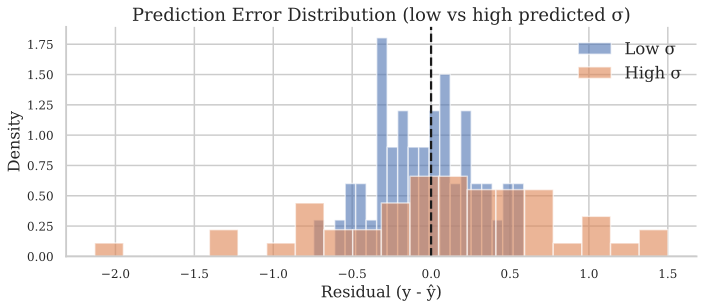

In [177]:
residuals = Y_np - np.interp(X_np, xs_np, mu_med)
low_sigma_mask = np.interp(X_np, xs_np, sig_med) < np.median(sig_med)
high_sigma_mask = ~low_sigma_mask

plt.figure(figsize=(10,4.5))
plt.hist(residuals[low_sigma_mask], bins=20, alpha=0.6, label="Low σ", density=True)
plt.hist(residuals[high_sigma_mask], bins=20, alpha=0.6, label="High σ", density=True)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel("Residual (y - ŷ)")
plt.ylabel("Density")
plt.title("Prediction Error Distribution (low vs high predicted σ)")
plt.legend()
plt.tight_layout()
plt.show()

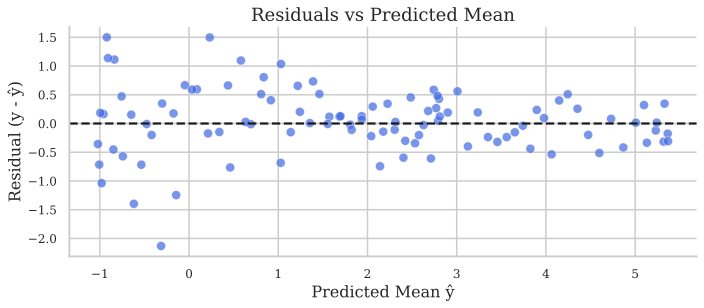

In [185]:
plt.figure(figsize=(10, 4.5))
plt.scatter(
    np.interp(X_np, xs_np, mu_med),
    residuals,
    alpha=0.7,
    c="royalblue",
    edgecolors="white",
    linewidths=0.5
)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Predicted Mean ŷ")
plt.ylabel("Residual (y - ŷ)")
plt.title("Residuals vs Predicted Mean")
plt.tight_layout()
plt.show()

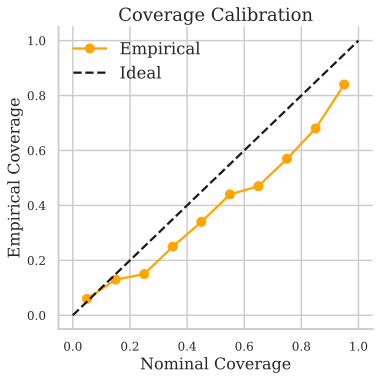

In [191]:
nominal_levels = np.linspace(0.05, 0.95, 10)
empirical_cov = []
for level in nominal_levels:
    lower = np.percentile(mu_grid, (1-level)*50, axis=0)
    upper = np.percentile(mu_grid, 100 - (1-level)*50, axis=0)
    emp_cov = np.mean(
        (Y_np >= np.interp(X_np, xs_np, lower)) &
        (Y_np <= np.interp(X_np, xs_np, upper))
    )
    empirical_cov.append(emp_cov)

plt.figure(figsize=(5.5,5.5))
plt.plot(nominal_levels, empirical_cov, marker='o', color='orange', label="Empirical")
plt.plot([0,1], [0,1], 'k--', label="Ideal")
plt.xlabel("Nominal Coverage")
plt.ylabel("Empirical Coverage")
plt.title("Coverage Calibration")
plt.legend()
plt.tight_layout()
plt.show()

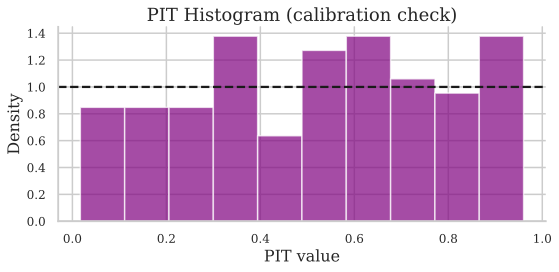

In [196]:
from scipy.stats import norm

pred_mu_at_X = np.interp(X_np, xs_np, mu_med)
pred_sigma_at_X = np.maximum(np.interp(X_np, xs_np, sig_med), 1e-12)
pit_values = norm.cdf(Y_np, loc=pred_mu_at_X, scale=pred_sigma_at_X)
plt.figure(figsize=(8,4))
plt.hist(pit_values, bins=10, density=True, alpha=0.7, color='purple')
plt.axhline(1, color='k', linestyle='--')
plt.xlabel("PIT value")
plt.ylabel("Density")
plt.title("PIT Histogram (calibration check)")
plt.tight_layout()
plt.show()

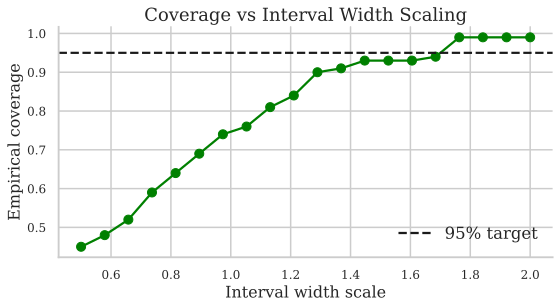

In [200]:
scales = np.linspace(0.5, 2.0, 20)
coverages = []
for s in scales:
    lo = mu_med - s * sig_med
    hi = mu_med + s * sig_med
    coverages.append(np.mean((Y_np >= np.interp(X_np, xs_np, lo)) & 
                             (Y_np <= np.interp(X_np, xs_np, hi))))

plt.figure(figsize=(8,4.5))
plt.plot(scales, coverages, marker='o', color='green')
plt.axhline(0.95, color='k', linestyle='--', label="95% target")
plt.xlabel("Interval width scale")
plt.ylabel("Empirical coverage")
plt.title("Coverage vs Interval Width Scaling")
plt.legend()
plt.tight_layout()
plt.show()

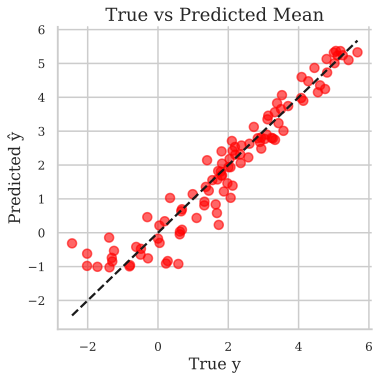

In [203]:
plt.figure(figsize=(5.5,5.5))
plt.scatter(Y_np, np.interp(X_np, xs_np, mu_med), color='red', alpha=0.6)
plt.plot([Y_np.min(), Y_np.max()], [Y_np.min(), Y_np.max()], 'k--')
plt.xlabel("True y")
plt.ylabel("Predicted ŷ")
plt.title("True vs Predicted Mean")
plt.tight_layout()
plt.show()

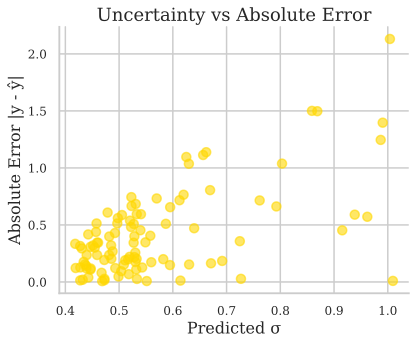

In [206]:
abs_error = np.abs(Y_np - np.interp(X_np, xs_np, mu_med))
pred_sigma = np.interp(X_np, xs_np, sig_med)

plt.figure(figsize=(6,5))
plt.scatter(pred_sigma, abs_error, color='gold', alpha=0.6)
plt.xlabel("Predicted σ")
plt.ylabel("Absolute Error |y - ŷ|")
plt.title("Uncertainty vs Absolute Error")
plt.tight_layout()
plt.show()

The model predicts the mean accurately and its uncertainty estimates generally track the variability in the data, but the predicted intervals are slightly too wide. We can still improve it.

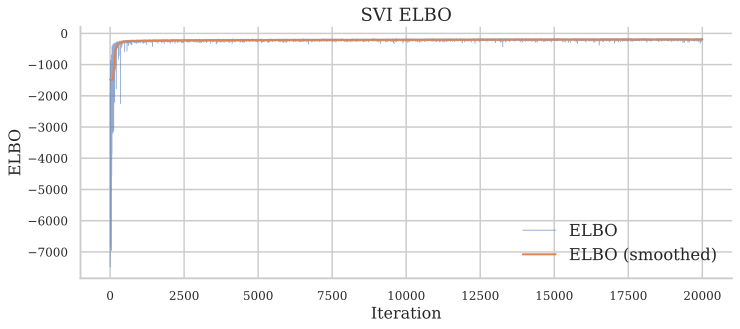

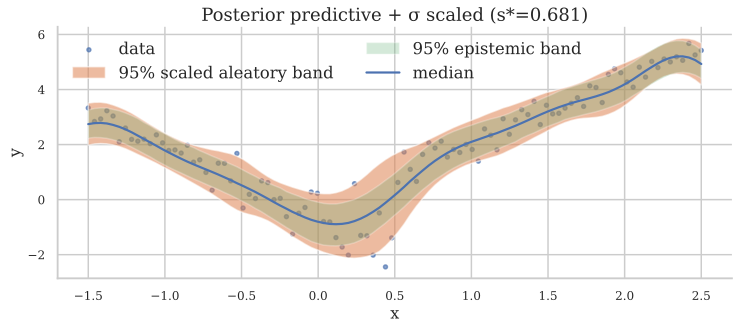

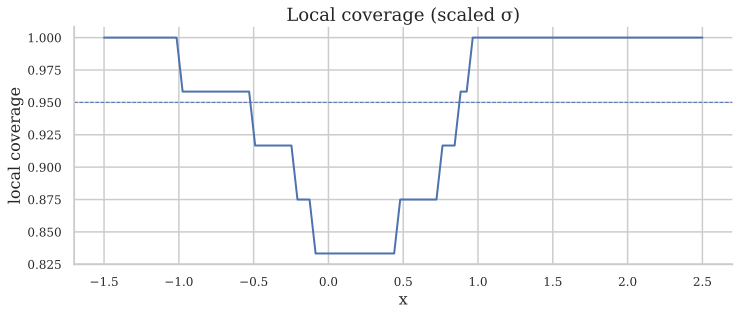

{'RMSE': 0.5645869665686596, 'Cov@X': 0.95, 'Width@X': 1.7174781602183051, 'LPPD(model)': -68.03632107704085, 'scale*': np.float64(0.6807469335095635)}


In [208]:
import numpy as np
import torch
import pyro
import pyro.distributions as dist
import pyro.optim
import pyro.infer
import pyro.infer.autoguide
import matplotlib.pyplot as plt
from scipy.stats import norm

torch.set_default_dtype(torch.double)

def compute_rbf(xc, ell, x):
    d2 = torch.cdist(x, xc) ** 2
    return torch.exp(-0.5 * d2 / (ell ** 2))

def to_np(x):
    a = x.detach().cpu().numpy()
    return a.reshape(a.shape[0], -1) if a.ndim >= 3 else a

def project_gp(Kxz, Kzz, gz):
    m = Kzz.size(-1)
    if gz.dim() == 1:
        alpha = torch.linalg.solve(Kzz, gz.unsqueeze(-1)).squeeze(-1)
        return Kxz @ alpha
    S = gz.shape[0]
    K = Kzz.expand(S, m, m)
    alpha = torch.linalg.solve(K, gz.unsqueeze(-1)).squeeze(-1)
    return torch.einsum('nm,sm->sn', Kxz, alpha)

def hetero_model(X, y, M=50):
    N = X.shape[0]
    xmin, xmax = X.min(), X.max()
    xc_f = torch.linspace(xmin, xmax, M, dtype=X.dtype, device=X.device).unsqueeze(-1)
    with pyro.plate("w_mean_plate", M):
        s_wm = pyro.sample("s_wm", dist.HalfNormal(0.6))
        w_mean = pyro.sample("w_mean", dist.Normal(0.0, s_wm))
    ell_mean = pyro.sample("ell_mean", dist.LogNormal(torch.log(torch.tensor(0.5, dtype=X.dtype, device=X.device)), 0.5))
    Phi_f = compute_rbf(xc_f, ell_mean, X)
    mean = Phi_f @ w_mean
    Mz = 25
    Z = torch.linspace(xmin, xmax, Mz, dtype=X.dtype, device=X.device).unsqueeze(-1)
    ell_g = pyro.sample("ell_g", dist.LogNormal(torch.log(torch.tensor(0.35, dtype=X.dtype, device=X.device)), 0.6))
    rho_g = pyro.sample("rho_g", dist.HalfNormal(1.0))
    Kzz = rho_g**2 * compute_rbf(Z, ell_g, Z) + 1e-5 * torch.eye(Mz, dtype=X.dtype, device=X.device)
    gz = pyro.sample("g_z", dist.MultivariateNormal(torch.zeros(Mz, dtype=X.dtype, device=X.device), covariance_matrix=Kzz))
    Kxz = compute_rbf(Z, ell_g, X)
    gX = project_gp(Kxz, Kzz, gz)
    if gX.dim() > 1:
        gX = gX.squeeze(0)
    b_sigma = pyro.sample("b_sigma", dist.Normal(-0.3, 0.5))
    log_sigma = gX + b_sigma
    sigma_base = torch.nn.functional.softplus(log_sigma) + 1e-6
    Mt = 30
    xc_t = torch.linspace(xmin, xmax, Mt, dtype=X.dtype, device=X.device).unsqueeze(-1)
    ell_t = pyro.sample("ell_tau", dist.LogNormal(torch.log(torch.tensor(0.6, dtype=X.dtype, device=X.device)), 0.5))
    with pyro.plate("w_tau_plate", Mt):
        s_ut = pyro.sample("s_ut", dist.HalfNormal(0.2))
        w_tau = pyro.sample("w_tau", dist.Normal(0.0, s_ut))
    Phi_t = compute_rbf(xc_t, ell_t, X)
    tau_x = torch.nn.functional.softplus(Phi_t @ w_tau) + 1.0
    sigma = (tau_x * sigma_base).clamp_min(1e-6)
    with pyro.plate("data", N):
        pyro.sample("y", dist.Normal(mean, sigma), obs=y)

def train_svi(model, guide, data, lr=0.004, iters=20000):
    pyro.clear_param_store()
    opt = pyro.optim.Adam({"lr": lr})
    svi = pyro.infer.SVI(model, guide, opt, pyro.infer.Trace_ELBO())
    X, y, M = data
    elbos = []
    for _ in range(iters):
        elbos.append(-svi.step(X, y, M))
    return np.asarray(elbos, float)

def predictive(X, y_unused=None, M=50):
    xmin, xmax = X.min(), X.max()
    xs = torch.linspace(xmin, xmax, 100, dtype=X.dtype, device=X.device).unsqueeze(-1)
    xc_f = torch.linspace(xmin, xmax, M, dtype=X.dtype, device=X.device).unsqueeze(-1)
    with pyro.plate("w_mean_plate", M):
        s_wm = pyro.sample("s_wm", dist.HalfNormal(0.6))
        w_mean = pyro.sample("w_mean", dist.Normal(0.0, s_wm))
    ell_mean = pyro.sample("ell_mean", dist.LogNormal(torch.log(torch.tensor(0.5, dtype=X.dtype, device=X.device)), 0.5))
    Phi_f = compute_rbf(xc_f, ell_mean, xs)
    pred = Phi_f @ w_mean
    Mz = 25
    Z = torch.linspace(xmin, xmax, Mz, dtype=X.dtype, device=X.device).unsqueeze(-1)
    ell_g = pyro.sample("ell_g", dist.LogNormal(torch.log(torch.tensor(0.35, dtype=X.dtype, device=X.device)), 0.6))
    rho_g = pyro.sample("rho_g", dist.HalfNormal(1.0))
    Kzz = rho_g**2 * compute_rbf(Z, ell_g, Z) + 1e-5 * torch.eye(Mz, dtype=X.dtype, device=X.device)
    gz = pyro.sample("g_z", dist.MultivariateNormal(torch.zeros(Mz, dtype=X.dtype, device=X.device), covariance_matrix=Kzz))
    Kxz = compute_rbf(Z, ell_g, xs)
    gX = project_gp(Kxz, Kzz, gz)
    b_sigma = pyro.sample("b_sigma", dist.Normal(-0.3, 0.5))
    log_sigma = gX + b_sigma
    sigma_base = torch.nn.functional.softplus(log_sigma) + 1e-6
    Mt = 30
    xc_t = torch.linspace(xmin, xmax, Mt, dtype=X.dtype, device=X.device).unsqueeze(-1)
    ell_t = pyro.sample("ell_tau", dist.LogNormal(torch.log(torch.tensor(0.6, dtype=X.dtype, device=X.device)), 0.5))
    with pyro.plate("w_tau_plate", Mt):
        s_ut = pyro.sample("s_ut", dist.HalfNormal(0.2))
        w_tau = pyro.sample("w_tau", dist.Normal(0.0, s_ut))
    Phi_t = compute_rbf(xc_t, ell_t, xs)
    tau_x = torch.nn.functional.softplus(Phi_t @ w_tau) + 1.0
    sigma = (tau_x * sigma_base).clamp_min(1e-6)
    pyro.deterministic("predictions", pred)
    pyro.deterministic("sigma", sigma)
    pyro.sample("predictions_with_noise", dist.Normal(pred, sigma))

def movavg(a, w=200):
    a = np.asarray(a, float)
    if w <= 1 or w >= len(a): return a
    c = np.convolve(a, np.ones(w)/w, mode="valid")
    pad = (w - 1)//2
    return np.pad(c, (pad, len(a)-len(c)-pad), mode="edge")

def logsumexp(x, axis=0):
    m = np.max(x, axis=axis, keepdims=True)
    return (m + np.log(np.sum(np.exp(x - m), axis=axis, keepdims=True))).squeeze(axis)

def local_cov(x, y, lo, hi, k=25):
    o = np.argsort(x)
    x = x[o]; y = y[o]; lo = lo[o]; hi = hi[o]
    r = []
    half = max(1, k//2)
    for i in range(len(x)):
        L = max(0, i - half); R = min(len(x), i + half)
        r.append(np.mean((y[L:R] >= lo[L:R]) & (y[L:R] <= hi[L:R])))
    return x, np.array(r)

if __name__ == "__main__":
    np.random.seed(0)
    N = 100
    x = np.linspace(-1.5, 2.5, N)
    f = np.where(x < -0.5, -2.0*x - 0.2, np.where(x < 0.5, -1.5*x - 0.5, 2.0*x + 0.3))
    sig_true = 0.3 + 0.5*np.exp(-((x-0.5)**2)*2.0)
    y = f + sig_true*np.random.randn(N)
    X = torch.tensor(x, dtype=torch.double).unsqueeze(-1)
    Y = torch.tensor(y, dtype=torch.double)
    M = 50

    guide = pyro.infer.autoguide.AutoDiagonalNormal(hetero_model)
    elbos = train_svi(hetero_model, guide, (X, Y, M), lr=0.004, iters=20000)

    S = 1200
    post = pyro.infer.Predictive(predictive, guide=guide, num_samples=S)(X, Y, M)
    xs = torch.linspace(X.min(), X.max(), 100, dtype=X.dtype, device=X.device).unsqueeze(-1)
    xs_np = xs.squeeze(-1).detach().cpu().numpy()
    X_np = X.detach().cpu().numpy().ravel()
    Y_np = Y.detach().cpu().numpy().ravel()

    mu_grid = to_np(post["predictions"])
    sig_grid = to_np(post["sigma"])
    mu_med = np.median(mu_grid, axis=0)
    sig_med = np.median(sig_grid, axis=0)

    z = norm.ppf(0.975)

    def cov_for_scale(s):
        lo = mu_med - z * (s * sig_med)
        hi = mu_med + z * (s * sig_med)
        lo_X = np.interp(X_np, xs_np, lo)
        hi_X = np.interp(X_np, xs_np, hi)
        return float(np.mean((Y_np >= lo_X) & (Y_np <= hi_X)))

    scales0 = np.linspace(0.6, 2.0, 30)
    covs0 = np.array([cov_for_scale(s) for s in scales0])
    target = 0.95
    idx = np.searchsorted(covs0, target) if covs0[0] <= covs0[-1] else np.searchsorted(covs0[::-1], target)
    if (covs0 < target).all():
        s_lo, s_hi = scales0[-2], scales0[-1]
    elif (covs0 > target).all():
        s_lo, s_hi = scales0[0], scales0[1]
    else:
        j = np.argmax(covs0 >= target)
        s_lo, s_hi = scales0[max(0, j-1)], scales0[j]

    for _ in range(16):
        s_mid = 0.5*(s_lo + s_hi)
        cov_mid = cov_for_scale(s_mid)
        if cov_mid < target:
            s_lo = s_mid
        else:
            s_hi = s_mid
    scale = 0.5*(s_lo + s_hi)

    sig_med_scaled = scale * sig_med
    sig_grid_scaled = scale * sig_grid
    lo_grid = mu_med - z * sig_med_scaled
    hi_grid = mu_med + z * sig_med_scaled

    mu_med_X = np.interp(X_np, xs_np, mu_med)
    lo_X = np.interp(X_np, xs_np, lo_grid)
    hi_X = np.interp(X_np, xs_np, hi_grid)
    rmse = float(np.sqrt(np.mean((Y_np - mu_med_X) ** 2)))
    cov = float(np.mean((Y_np >= lo_X) & (Y_np <= hi_X)))
    wid = float(np.mean(hi_X - lo_X))
    idxn = np.searchsorted(xs_np, X_np).clip(1, len(xs_np) - 1)
    near = np.where(np.abs(xs_np[idxn] - X_np) < np.abs(xs_np[idxn-1] - X_np), idxn, idxn-1)
    mu_X = mu_grid[:, near]
    sig_X = sig_grid_scaled[:, near].clip(1e-12)
    ll = -0.5*np.log(2*np.pi) - np.log(sig_X) - 0.5*((Y_np[None,:]-mu_X)/sig_X)**2
    lppd = float(np.sum(logsumexp(ll, axis=0) - np.log(ll.shape[0])))

    plt.rcParams.update({"font.family":"serif","font.size":14,"axes.labelsize":16,"axes.titlesize":18,"xtick.labelsize":12,"ytick.labelsize":12,"axes.spines.top":False,"axes.spines.right":False})

    plt.figure(figsize=(10.5,4.8))
    plt.plot(elbos, alpha=.6, lw=.9, label="ELBO")
    plt.plot(movavg(elbos,200), lw=2, label="ELBO (smoothed)")
    plt.xlabel("Iteration"); plt.ylabel("ELBO"); plt.title("SVI ELBO"); plt.legend(frameon=False); plt.tight_layout(); plt.show()

    p025, p975 = [a.ravel() for a in np.percentile(mu_grid, [2.5,97.5], axis=0)]
    plt.figure(figsize=(10.5,4.8))
    plt.scatter(X_np, Y_np, s=16, alpha=.65, label="data", zorder=1)
    plt.fill_between(xs_np, lo_grid, hi_grid, alpha=.55, label="95% scaled aleatory band", zorder=2)
    plt.fill_between(xs_np, p025, p975, alpha=.25, label="95% epistemic band", zorder=3)
    plt.plot(xs_np, mu_med, lw=2.2, label="median", zorder=4)
    plt.xlabel("x"); plt.ylabel("y"); plt.title(f"Posterior predictive + σ scaled (s*={scale:.3f})"); plt.legend(frameon=False, ncol=2, loc="upper left"); plt.tight_layout(); plt.show()

    Xs, covs = local_cov(X_np, Y_np, lo_X, hi_X, k=25)
    plt.figure(figsize=(10.5,4.6))
    plt.plot(Xs, covs, lw=2)
    plt.axhline(0.95, lw=1, linestyle="--")
    plt.xlabel("x"); plt.ylabel("local coverage"); plt.title("Local coverage (scaled σ)"); plt.tight_layout(); plt.show()

    print({"RMSE": rmse, "Cov@X": cov, "Width@X": wid, "LPPD(model)": lppd, "scale*": scale})


Scaling the predicted standard deviations down by about 0.68× brings the empirical coverage to the 95% target while keeping point prediction accuracy essentially unchanged.